In [268]:
from datetime import datetime
import pandas as pd
import seaborn as sns
import numpy as np

In [371]:
nifty_price_df = pd.read_csv("NIFTY50.csv").dropna()[["Date","Close"]]
nifty_price_df["Date"] = pd.to_datetime(nifty_price_df["Date"]).apply(lambda x:x.date())
nifty_price_df["date_str"] = nifty_price_df["Date"].apply(lambda x:str(x)[:10])

In [372]:
nifty_pe_df = pd.read_csv("NIFTY50-PE.csv").dropna()[["Date","P/E"]]
nifty_pe_df["Date"] = pd.to_datetime(nifty_pe_df["Date"]).apply(lambda x:x.date())
nifty_pe_df["date_str"] = nifty_pe_df["Date"].apply(lambda x:str(x)[:10])

In [373]:
joined_df = nifty_price_df.set_index("date_str").join(nifty_pe_df.set_index("date_str"),how="inner",lsuffix="_l").reset_index()[["Date","Close","P/E"]]

In [374]:
joined_df = joined_df[joined_df["Date"].apply(lambda x:x > datetime(2013,1,1).date())]

<Axes: xlabel='Date', ylabel='P/E'>

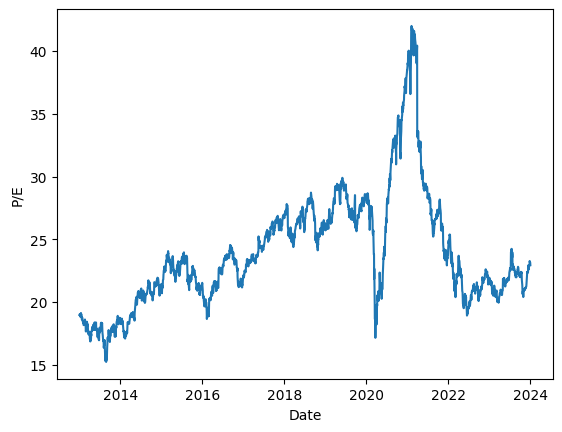

In [375]:
sns.lineplot(x=joined_df["Date"],y=joined_df["P/E"])

In [376]:
joined_df["P/E"].median()

23.08

In [377]:
joined_df["P/E"].std()

4.626937372711831

In [378]:
np.percentile(joined_df["P/E"],q=[25,50,75,90,99])

array([20.92  , 23.08  , 26.5225, 29.007 , 40.1554])

In [379]:
joined_df["Date+X"] = joined_df["Date"].apply(lambda x:x+rd.relativedelta(years=2))

In [380]:
date_to_price_dict = dict(zip(joined_df["Date"],joined_df["Close"]))

In [381]:
def get_price_from_dict(date):
    if date > datetime.today().date():
        return None
    for i in range(10):
        if date in date_to_price_dict:
            return date_to_price_dict[date]
        else:
            date = date + rd.relativedelta(days=1)
    return None

In [382]:
joined_df["Date+X_Price"] = joined_df["Date+X"].apply(get_price_from_dict)

In [383]:
joined_df1 = joined_df.dropna()

In [384]:
def calculate_cagr(start, end, n):
    cagr = (end / start) ** (1 / n) - 1
    return round(100*cagr,2)

In [385]:
joined_df1["CAGR"] = joined_df1.apply(lambda x:calculate_cagr(x.Close,x["Date+X_Price"],2),axis=1)

/tmp/ipykernel_14794/885198801.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [386]:
joined_df1.sample(10)

,Date,Close,P/E,Date+X,Date+X_Price,CAGR
1175,2019-04-05,11665.95,29.12,2021-04-05,14637.80,12.02
2074,2015-08-17,8477.30,23.48,2017-08-17,9904.10,8.09
617,2021-07-08,15727.90,28.34,2023-07-08,19355.90,10.94
2558,2013-08-29,5409.00,15.59,2015-08-29,7971.30,21.40
890,2020-06-08,10167.45,23.97,2022-06-08,16356.25,26.83
2016,2015-11-11,7825.00,21.17,2017-11-11,10224.00,14.31
2371,2014-06-03,7415.80,20.46,2016-06-03,8220.80,5.29
1603,2017-07-14,9886.30,25.12,2019-07-14,11588.35,8.27
2577,2013-07-31,5742.00,17.05,2015-07-31,8532.80,21.90
1495,2017-12-19,10463.00,26.79,2019-12-19,12259.70,8.25


In [405]:
def PE_bucket(pe_ratio):
    if pe_ratio <= 15:
        return "10-15"
    if pe_ratio <= 20:
        return "15-20"
    if pe_ratio <= 25:
        return "20-25"
    if pe_ratio <= 30:
        return "25-30"
    else:
        return "30+"

In [406]:
joined_df1["PE_bucket"] = joined_df1["P/E"].apply(PE_bucket)

In [409]:
joined_df1["P/E"].max()

29.98

In [407]:
joined_df1["PE_bucket"].value_counts()

PE_bucket
20-25    860
25-30    788
15-20    385
Name: count, dtype: int64

In [390]:
joined_df1 = joined_df1.dropna()

In [391]:
joined_df1.groupby("PE_bucket")["CAGR"].mean()

PE_bucket
15-20    17.027377
20-25    10.645453
25-30    10.454226
Name: CAGR, dtype: float64

In [392]:
PE_to_CAGR = dict(joined_df1.groupby("PE_bucket")["CAGR"].mean())

In [393]:
joined_df1[["P/E","CAGR"]].corr().iloc[0][1]

/tmp/ipykernel_14794/3349045699.py:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



-0.2111126423029235

In [394]:
joined_df1["CAGR"].mean()

11.77991146089523

<Axes: xlabel='Date', ylabel='P/E'>

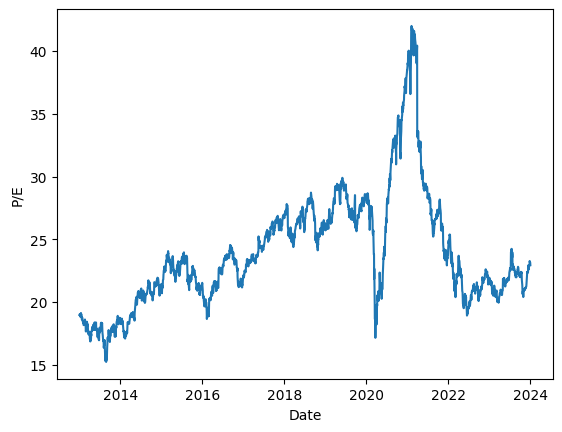

In [395]:
sns.lineplot(x=joined_df["Date"],y=joined_df["P/E"])

In [396]:
joined_df["PE_bucket"] = joined_df["P/E"].apply(PE_bucket)

In [397]:
PE_to_CAGR

{'15-20': 17.02737662337662,
 '20-25': 10.645453488372093,
 '25-30': 10.454225888324874}

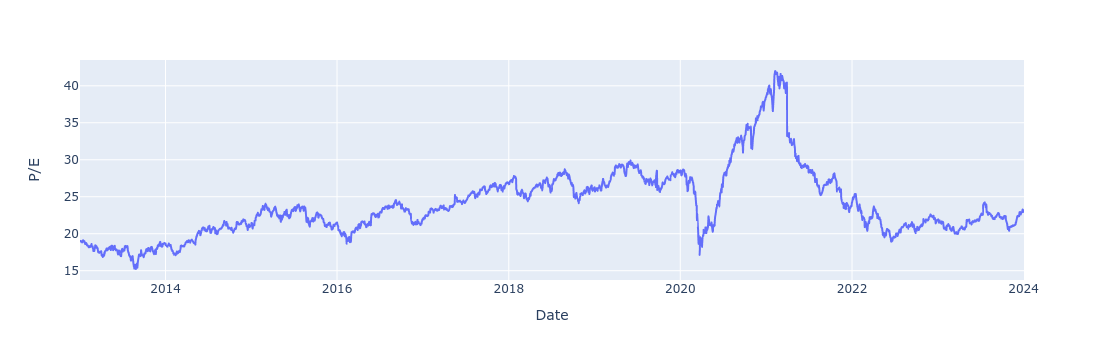

In [398]:
import plotly.express as px

fig = px.line(joined_df, x="Date", y="P/E")
fig.show()

In [426]:
pe_df = pd.DataFrame(zip(range(0,100,10),np.percentile(joined_df[joined_df["Date"]\
        .apply(lambda x:x > datetime(2010,1,1).date())]["P/E"],q=range(0,100,10))),columns=["percentile","pe"])

In [412]:
joined_df[joined_df["Date"].apply(lambda x:x > datetime(2013,1,1).date())]["P/E"].std()

4.626937372711831

In [414]:
23

23

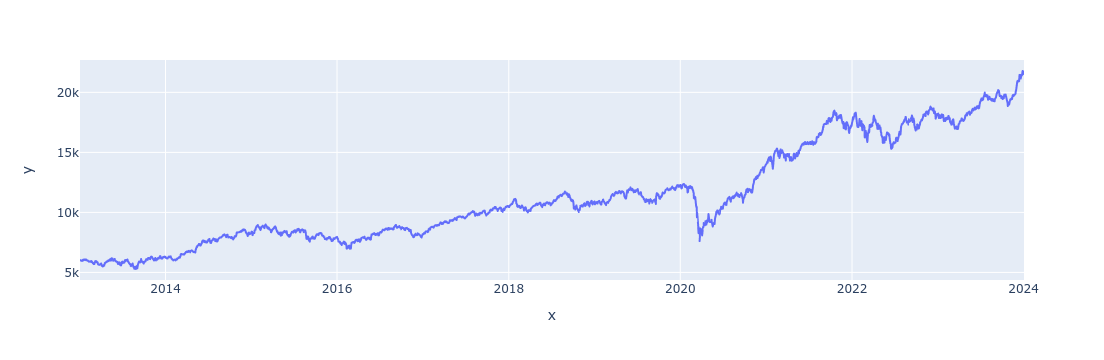

In [402]:
px.line(x=joined_df["Date"],y=joined_df["Close"])

In [403]:
joined_df["Year"] = joined_df["Date"].apply(lambda x:x.year)

In [404]:
joined_df.groupby("Year")["P/E"].median()

Year
2013    17.850
2014    20.425
2015    22.495
2016    21.680
2017    24.835
2018    26.335
2019    27.700
2020    28.385
2021    28.530
2022    21.340
2023    21.675
2024    23.100
Name: P/E, dtype: float64

### Conclusions
- anything under 20 is rare. invest a lot

In [431]:
pe_df

,percentile,pe
0,0,15.230
1,10,18.543
2,20,20.550
3,30,21.260
4,40,22.082
5,50,23.080
6,60,24.090
7,70,25.981
8,80,27.160
9,90,29.007


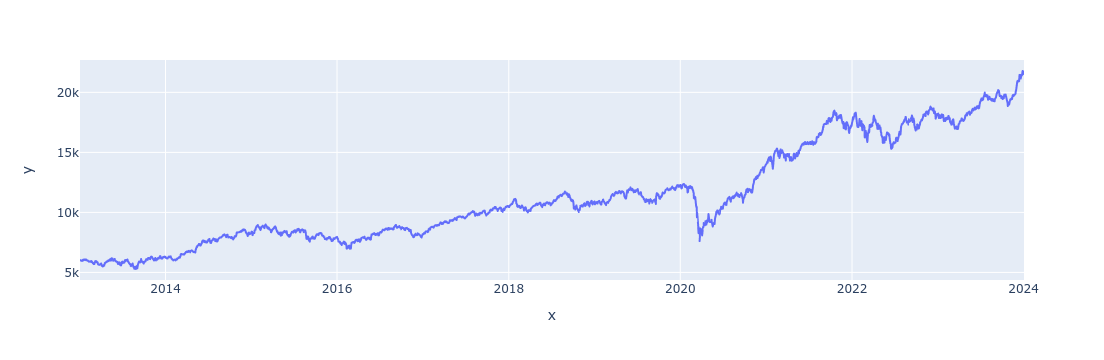

In [433]:
px.line(x=joined_df["Date"],y=joined_df["Close"],hover_name=joined_df["P/E"])